<a href="https://colab.research.google.com/github/abhishek18-blog/DataScience-and-ML/blob/main/market_basket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Chunk 1: Data Cleaning & Encoding (EX2004-3)
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# Load your transactions
df = pd.read_csv('/content/transactions.csv')

# Clean: Remove empty rows and strip whitespace
df.dropna(inplace=True)
df['Item'] = df['Item'].str.strip().str.lower()

# Group by ID into a list of lists
transactions = df.groupby('TransactionID')['Item'].apply(list).values.tolist()

# Transform into a Boolean Matrix (One-Hot Encoding)
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
encoded_df = pd.DataFrame(te_ary, columns=te.columns_)

print("✅ Chunk 1 Complete: Data is cleaned and encoded.")

✅ Chunk 1 Complete: Data is cleaned and encoded.


In [3]:
#CHUNK 2: Algorithm Execution (EX2004-4)
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Find Frequent Itemsets
frequent_itemsets = apriori(encoded_df, min_support=0.01, use_colnames=True)

# 2. Generate Rules based on Lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# 3. Filter for Confidence > 0.5
final_rules = rules[rules['confidence'] > 0.5].sort_values('lift', ascending=False)

print(f"✅ Chunk 2 Complete: Found {len(final_rules)} strong rules.")

✅ Chunk 2 Complete: Found 256 strong rules.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

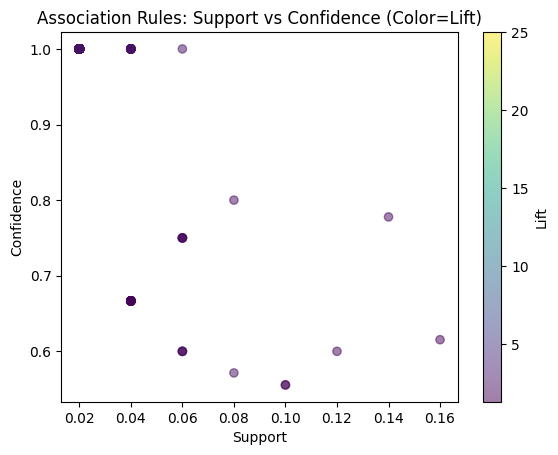

✅ Chunk 3 Complete: CSV and Plot generated.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
import matplotlib.pyplot as plt

# 1. Export results to CSV for the Jira attachment
final_rules.to_csv('top_association_rules.csv', index=False)

# 2. Create the Scatter Plot
plt.scatter(final_rules['support'], final_rules['confidence'], alpha=0.5, c=final_rules['lift'], cmap='viridis')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence (Color=Lift)')
plt.colorbar(label='Lift')
plt.savefig('rules_visualization.png')
plt.show()

print("✅ Chunk 3 Complete: CSV and Plot generated.")